# Ìmọ̀lára — 01 · Exploratory Data Analysis

**Data:** AfriSenti-SemEval 2023, Yoruba (`yor`): raw TSVs from the official repository, pinned to commit `5aec3cf` (`src/data.py`).
**Purpose:** understand the data before modelling, and record every preprocessing decision with the evidence behind it.

All numbers come from `src/eda.py` (`python -m src.eda` regenerates `results/data_stats.json` and the figures). This notebook only presents them.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import eda
from src.data import LABELS, normalize_semeval, nfc, overlaps_with, strip_tones, strip_all_diacritics

pd.set_option("display.max_colwidth", 120)
data = eda.load_all()
stats = eda.compute_all_stats(data)
figs = eda.make_figures(data, stats)
pd.Series(stats["sizes"], name="tweets").to_frame().T

,train,dev,test
tweets,8522,2090,4515


## 1 · Labels

Three classes. The split proportions are almost identical (stratified by the organisers). **Negative is the minority class (about 22%)**, so we use **macro-F1** as the primary metric (every class counts equally) and also report the official SemEval metric, **weighted-F1**.

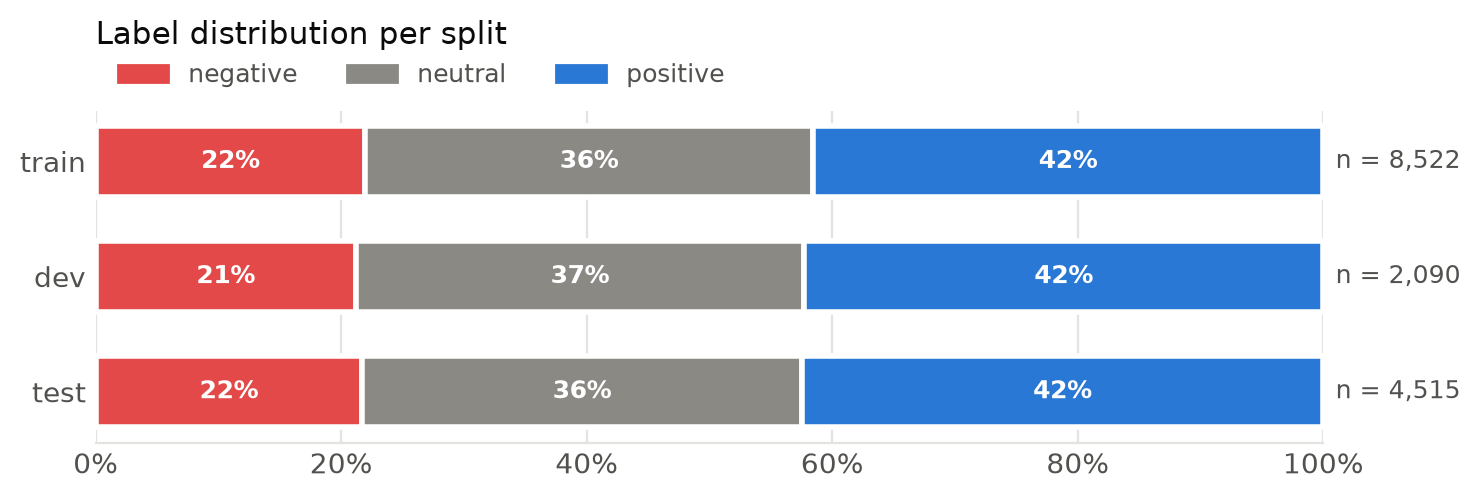

,train,dev,test
negative,1872,443,981
neutral,3108,763,1616
positive,3542,884,1918


In [2]:
display(Image(figs[0]))
pd.DataFrame({s: {l: v["count"] for l, v in stats["labels"][s].items()} for s in eda.SPLITS})

## 2 · The train/test format mismatch (key finding)

The released **test split was pre-normalised by the organisers**: it is lower-cased, and mentions, URLs, `RT`, hashtags, punctuation, digits and emojis were removed. **Train and dev are raw tweets.** A model trained on raw text would see a different input distribution at test time, and could learn cues (emojis, hashtags such as `#ibeere` 'question', capitalisation) that never occur in test.

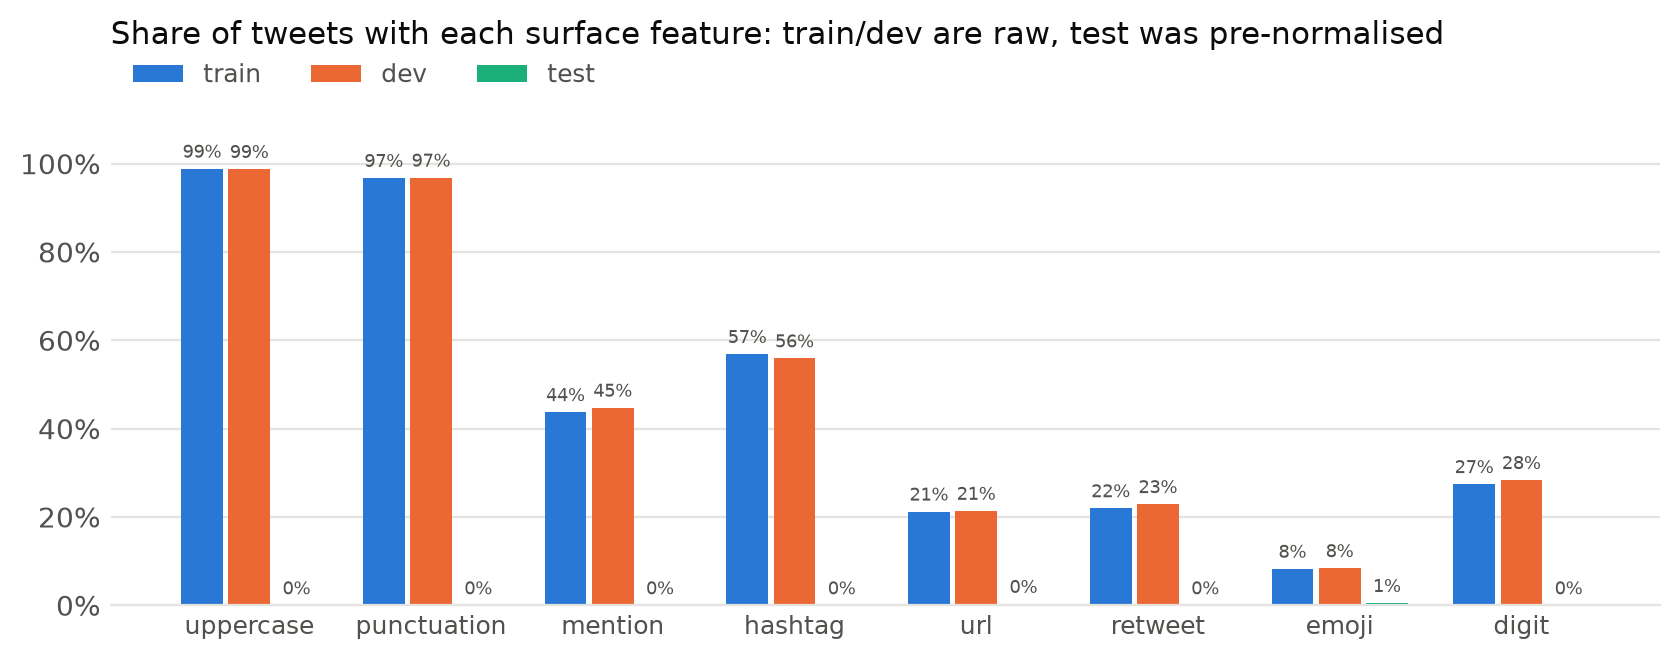

,train,dev,test
uppercase,98.9%,98.8%,0.0%
punctuation,96.8%,96.8%,0.0%
mention,43.8%,44.7%,0.0%
hashtag,56.9%,55.9%,0.0%
url,21.2%,21.4%,0.3%
retweet,22.0%,22.9%,0.0%
emoji,8.3%,8.4%,0.5%
digit,27.5%,28.4%,0.0%


In [3]:
display(Image(figs[1]))
pd.DataFrame(stats["surface_features_raw"]).style.format("{:.1%}")

**Decision:** apply the organisers' normalisation (`normalize_semeval`) to **every split**, in training, evaluation and the web app.

We reconstructed it from train/test pairs that are the same tweet. On the 79 pairs found with a conservative matching key, it reproduces **76/79 test strings exactly**; the 3 misses differ in the underlying tweet itself (e.g. an extra `$$$$`). Hashtags are removed *with* their word: `#tweetinyoruba` occurs in 251 training tweets and never in test. A raw-text variant (`style="raw"`) is kept as an ablation.

Examples (raw training tweet → normalised):

In [4]:
ex = data["train"].sample(5, random_state=3)[["text"]].copy()
ex["normalised"] = ex["text"].map(lambda t: normalize_semeval(nfc(t)))
ex

,text,normalised
5708,RT @user: Ki Olódùmarè Yọ wa kúrò nínú ajakale àrùn Coronavirus. May Almighty God save humanity from this virus. Sta...,ki olódùmarè yọ wa kúrò nínú ajakale àrùn coronavirus may almighty god save humanity from this virus stay safe avoid
4751,Ẹ̀jẹ̀ ibi awọ fẹ́lẹ́ ojú-ìgó; #ibale tí yóò ro sórí aṣọ àlà tí a tẹ́ sílẹ̀ ni yóò dúró gẹ́gẹ́ bí ẹ̀rí sí ìdílé ìyàwó...,ẹ̀jẹ̀ ibi awọ fẹ́lẹ́ ojú ìgó tí yóò ro sórí aṣọ àlà tí a tẹ́ sílẹ̀ ni yóò dúró gẹ́gẹ́ bí ẹ̀rí sí ìdílé ìyàwó
517,"Mo ti pè pè pè 111 títí síbẹ̀ kò sí àtúnṣe, gbogbo ohun tí wọ́n ní ń ṣe ni mo ti ṣe. @user @user @user",mo ti pè pè pè títí síbẹ̀ kò sí àtúnṣe gbogbo ohun tí wọ́n ní ń ṣe ni mo ti ṣe
6296,"Ọ̀nà àrìnyè fún onímọ́tò àti èrò. Ilẹ̀ òní yọ̀ wá, ọ̀nà òní nà wá",ọ̀nà àrìnyè fún onímọ́tò àti èrò ilẹ̀ òní yọ̀ wá ọ̀nà òní nà wá
3559,Orí ooo! Orí hu! 🙌🏾 #Orí #cultotradicionalyoruba #yoruba https://t.co/hndpdWKOgT,orí ooo orí hu


## 3 · Diacritics (tone marks and under-dots)

Yoruba marks tone with grave/acute accents and distinguishes ẹ/ọ/ṣ with an under-dot. Written Yoruba online often omits them (Orife, 2018), but **in this dataset about 77% of tweets carry tone marks**, probably because the tweets were collected with diacritised keywords. Users of the web app, however, will often type without diacritics, which motivates the robustness experiment **E6**.

**Confound:** diacritic *presence* differs by label. Neutral tweets carry tone marks most often (about 85%, many are educational "learn Yoruba" posts), negative tweets least (about 71%). A model can partly use "has diacritics" as a label cue; E6 measures how much performance depends on it.

In [5]:
rows = {s: {"tone marks": d["tone_marks"], "under-dots": d["underdots"], "no diacritics": d["no_diacritics"],
            **{f"tone marks | {l}": d["tone_marks_by_label"][l] for l in LABELS}}
        for s, d in stats["diacritics"].items()}
pd.DataFrame(rows).style.format("{:.1%}")

,train,dev,test
tone marks,77.2%,77.8%,78.5%
under-dots,72.9%,73.0%,73.9%
no diacritics,21.8%,21.6%,20.7%
tone marks | negative,71.4%,71.8%,70.1%
tone marks | neutral,85.3%,86.1%,87.2%
tone marks | positive,73.3%,73.5%,75.3%


In [6]:
t = "Ẹ kú àbọ̀, ọ̀rẹ́ mi! Ọlọ́run á bùkún yín."
pd.Series({"original": t, "no_tones (E6)": strip_tones(t), "no_diacritics (E6)": strip_all_diacritics(t)})

original              Ẹ kú àbọ̀, ọ̀rẹ́ mi! Ọlọ́run á bùkún yín.
no_tones (E6)             Ẹ ku abọ, ọrẹ mi! Ọlọrun a bukun yin.
no_diacritics (E6)        E ku abo, ore mi! Olorun a bukun yin.
dtype: str

## 4 · Tweet length

After normalisation the median tweet has **18 tokens** (95th percentile about 45). Negative tweets are slightly longer (median 20). With subword tokenisation, `max_length = 128` comfortably covers almost every tweet.

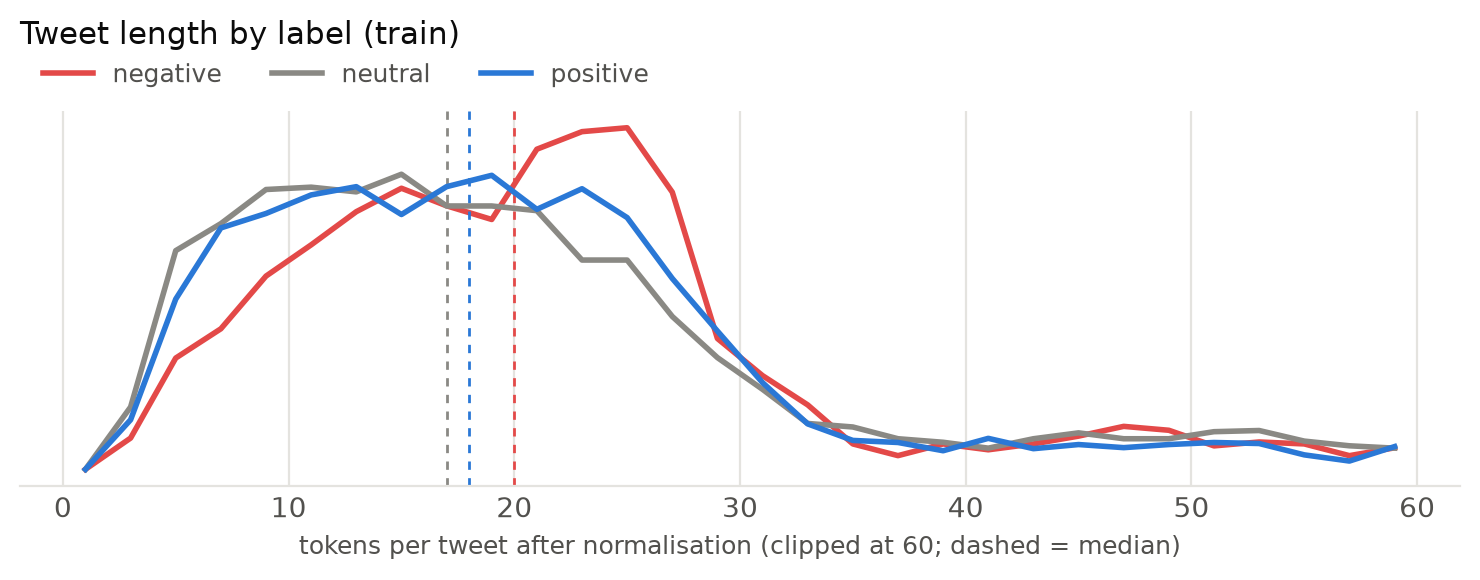

,train,dev,test
mean,19.4,19.3,19.2
median,18.0,18.0,18.0
p95,45.0,46.0,43.0
max,70.0,62.0,69.0


In [7]:
display(Image(figs[2]))
pd.DataFrame({s: {k: v for k, v in d.items() if k != "by_label_median"} for s, d in stats["length_tokens_normalised"].items()})

## 5 · Vocabulary and out-of-vocabulary words

Word-level out-of-vocabulary (OOV) rates relative to the training vocabulary. **Test is lexically further from train than dev** (41% vs 29% of word *types* unseen). Ignoring diacritics shrinks the vocabulary by about 30% and cuts the token OOV rate by about a third. This argues for subword or character models (char n-gram TF-IDF, fastText subwords, Transformer tokenisers) over word-level ones.

In [8]:
pd.DataFrame({(s, k): v for s, d in stats["vocabulary"].items() for k, v in d.items()}).T

train_vocab_size  oov_token_rate  oov_type_rate
dev  with_diacritics              20052.0          0.0657         0.2896
     without_diacritics           14164.0          0.0419         0.2496
test with_diacritics              20052.0          0.0776         0.4056
     without_diacritics           14164.0          0.0521         0.3709

## 6 · Train/dev/test overlap (leakage)

Comparing tweets after normalisation **and** diacritic stripping, **13% of dev and 8.5% of test tweets duplicate a training tweet** (retweets, the same proverb posted twice, the same tweet with different hashtags). About 96% of those keep the same label. Duplicates inflate scores, and on dev they also bias model selection towards memorisation.

**Decisions:**
* the official splits are kept unchanged, for comparability with published results;
* every evaluation reports the **full** split and a **clean** subset without train duplicates (`evaluate.score_subsets`);
* the best epoch or hyperparameters are chosen on **clean dev** (1,817 tweets).

In [9]:
pd.DataFrame({k: v for k, v in stats["overlap"].items() if isinstance(v, dict)}).T

,overlapping,share,same_label_as_train,different_label
dev,273.0,0.1306,262.0,11.0
test,386.0,0.0855,371.0,15.0


In [10]:
dup = data["test"][overlaps_with(data["test"], data["train"])].head(4)[["text", "label"]]
dup

,text,label
8,irú ẹṣin ní í gbẹ́ṣin ga,positive
11,️eni ni ojo eti ojo kejidinlogbon odun ojo ti awa omo yoruba omo karo o ji ire ojo ifi gbe àṣà yorùbá lárugẹ,positive
13,apa lara igunpa niyekan oun ti a ba si fara sise fun oun nii pe lowo eni e je ka mura sise wa eyin ore mi nitori osi...,positive
23,amin o beno lo ma se ri fun gbogbo ninu osu yi,positive


## 7 · Code-switching with English (heuristic estimate)

A token is counted as English if it is plain ASCII, at least 4 letters long, appears in an English wordlist, and is never written with Yoruba diacritics anywhere in the corpus (so *ise*, a plain spelling of *iṣẹ́*, is not counted). A tweet with at least 2 such tokens is flagged. **About 14% of tweets are code-switched** by this measure. Many are bilingual "proverb + English translation" posts. It is a rough estimate: the examples below show it catches true code-switching, but it will miss short English words and Yoruba–English loan blends.

In [11]:
cs = stats["code_switching"]
display(pd.DataFrame({s: cs[s]["by_label"] | {"all": cs[s]["share_code_switched"]} for s in eda.SPLITS}).style.format("{:.1%}"))
print("Most frequent English tokens (train):", ", ".join(w for w, _ in cs["top_english_tokens_train"][:20]))
for e in cs["examples_train"][:5]:
    print("·", e)

,train,dev,test
negative,14.8%,16.2%,14.9%
neutral,15.6%,14.7%,15.2%
positive,13.0%,10.9%,11.9%
all,14.3%,13.4%,13.7%


Most frequent English tokens (train): that, with, will, this, what, have, your, nigeria, people, good, translation, from, happy, proverb, does, whoever, like, person, twitter, know
· yorùbá adage for the week àdánìkànrìn ejò ló ń jẹ ọmọ ejò níyà translation the lone movement of a snake exposes it to danger what is this òwe telling you
· ó ti wà bẹ́ẹ̀ lọ́jọ́ tó ti pẹ́ olóògbé bàbá alfredo darrington bowman tí àwọn èèyàn mọ̀ sí dr sebi ti ilé iṣẹ́ ìwádìí usha ní america ṣe àfihàn àwọn oúnjẹ ikú wọ̀nyí kódà ọ̀ràn náà só síni lẹ́nu ó tún buyọ̀ sí i nítorí owó
· àmodi illness ọdún méjì ni àmodi fi ṣe é s he was ill for years
· ede gesi yin gan o gbadun ewo ni right write ni sir eti fi owo awan obi yin jona
· ẹranko tó bá ṣiyèméjì lọde ńpa it is the indecisive animal that gets killed by the hunter proverb


## 8 · Class-distinctive words

Weighted log-odds with an informative Dirichlet prior (Monroe et al., 2008), each class vs the rest, on normalised training text. Higher z means more distinctive. The lists make sense:
* **negative:** *pa* 'kill', *ikú* 'death', *ìjọba* 'government', and third-person *wọ́n / awon* 'they' (complaints about others);
* **positive:** *ire* 'goodness, blessing', *(ẹ) kú* (greeting formula), *Ọlọ́run* 'God', *ajé* 'wealth';
* **neutral:** function words written with full diacritics, *yorùbá*, *orúkọ* 'name', *kíni* 'what is', the language of educational posts.

The neutral list again shows the **diacritic confound**: fully diacritised spellings (*tí, ní, àwọn*) mark neutral, while plain spellings (*awon, won*) lean negative.

In [12]:
pd.DataFrame({l: [f"{w} ({z})" for w, z in stats["distinctive_words_train"][l]] for l in LABELS})

,negative,neutral,positive
0,pa (11.02),tí (12.26),o (25.0)
1,wọ́n (10.42),ń (11.61),wa (19.62)
2,ti (10.17),ní (10.84),ẹ (19.39)
3,awon (9.93),yorùbá (10.42),ire (16.89)
4,won (9.85),orúkọ (9.8),mi (16.59)
5,ò (9.51),mọ̀ (9.52),kú (15.38)
6,wọn (8.15),sí (9.43),mo (12.95)
7,ba (7.76),ǹjẹ́ (9.3),gbogbo (11.69)
8,wan (7.39),ni (9.17),ki (11.25)
9,ikú (7.04),wípé (9.06),ọlọ́run (11.24)


## 9 · Auxiliary languages (for E7)

Training sizes for Hausa, Igbo and Nigerian Pidgin. **Pidgin has almost no neutral tweets (1.4%)**, so adding it skews the label prior. E7 should compare *all three* against *Hausa + Igbo only*.

In [13]:
pd.DataFrame({l: {"train": v["train_size"], **{k: f"{x['share']:.1%}" for k, x in v["labels"].items()}} for l, v in stats["aux_languages"].items()})

,hau,ibo,pcm
train,14172,10192,5121
negative,32.3%,25.5%,63.3%
neutral,34.7%,44.2%,1.4%
positive,33.1%,30.3%,35.3%


## 10 · Preprocessing decisions (summary)

| Decision | Evidence |
|---|---|
| Use raw TSVs at a pinned commit, not the HF copy | The HF dataset relies on a loading script that current `datasets` can't run; pinning makes results reproducible |
| NFC-normalise all text | The same Yoruba letter can be encoded in several ways |
| Apply `normalize_semeval` to **all** splits | Test is pre-normalised (§2); 76/79 pairs reproduced exactly |
| Keep official splits; report **all** + **clean** subsets; select on **clean dev** | 13% of dev and 8.5% of test duplicate train (§6) |
| Primary metric macro-F1; also weighted-F1 (official) | Negative is a 22% minority (§1) |
| Subword/character-aware models | High OOV, especially on test (§5) |
| Tone-mark ablation E6 (`no_tones`, `no_diacritics`, `mixed`) | 77% diacritised data vs undiacritised real-world input, plus the label confound (§3, §8) |
| E7 runs with and without Pidgin | Pidgin has 1.4% neutral (§9) |
